# MSCFE 690: Capstone Project
### Student Group: 11186

The notebook contains the development of a Bayesian Network (BN) model based on DYNOTEARS, and an example of how inferences can be used for utility optimization to estimate factor weight allocations.

This exercise is part of early idea & algorithm explorations, and represents an early proof-of-concept (PoC). This is NOT the final version of the workflow or the model. 

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import yfinance as yf
import pandas_datareader as web
import causalnex

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6,3)
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

print(f"platform:\t\t{sys.platform}")
print(f"python version:\t\t{sys.version}")
print(f"pandas version:\t\t{pd.__version__}")
print(f"numpy version:\t\t{np.__version__}")
print(f"matplotlib version:\t{matplotlib.__version__}")
print(f"yfinance version:\t{yf.__version__}")
print(f"pd-datareader version:\t{web.__version__}")
print(f"causalnex version:\t{causalnex.__version__}")

platform:		darwin
python version:		3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]
pandas version:		2.2.3
numpy version:		1.23.5
matplotlib version:	3.10.5
yfinance version:	0.2.65
pd-datareader version:	0.10.0
causalnex version:	0.12.1


Note: The DYNOTEARS model has been implemented in CausalNex library (https://github.com/mckinsey/causalnex/blob/develop/causalnex/structure/dynotears.py).

Note that it requires ```python_version <= 3.10```. This could be in conflict with the requirements for some other libraries we might want to use.

For more information on CausalNex, please refer to: https://github.com/mckinsey/causalnex/tree/develop and https://causalnex.readthedocs.io/en/latest/.

## Section 1 - Data Preparation

### 1.1 Data Processing

For more information on how the factor returns data were retrieved and processed, as well as an extensive EDA on them, please refer to: https://github.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/blob/main/notebooks/01_EDA_ETL.ipynb and https://github.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/blob/main/inputs/meta/etl_decisions.md.

In [2]:
# fetch data from previously processed csv by DS
import os
csv_path = "osap_factor_returns.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
else:
    url = "https://raw.githubusercontent.com/dipanshusharma2001/MScFE_WQU_Capstone_Project/main/inputs/clean/osap_factor_returns.csv"
    df = pd.read_csv(url)

# convert index to datetime format
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.index = df['date']
del df['date']

# convert returns to decimals
df = df / 100
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 1964-01-31 to 2023-12-29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          720 non-null    float64
 1   IdioVol3F   720 non-null    float64
 2   Investment  720 non-null    float64
 3   Mom12m      720 non-null    float64
 4   OperProf    720 non-null    float64
 5   Size        720 non-null    float64
dtypes: float64(6)
memory usage: 39.4 KB


In [3]:
# retrieve indices data from Yahoo Finance
start = df.index[0]
end = df.index[-1]

tick = ['^GSPC', '^RUT', 'DX-Y.NYB', '^IRX']
yfin_data = yf.download(tick,
                        start,
                        end,
                        auto_adjust=False,
                        progress=False)['Close']

# change variable names into something more intuitive
yfin_data = yfin_data.loc[:,tick]
yfin_data.columns.name = None
yfin_data.rename(columns = {
    '^GSPC': 'SP500',
    '^RUT': 'RSSL2K',
    'DX-Y.NYB': 'USDIDX',
    '^IRX': 'TBLL13WK'
    },
    inplace=True)

yfin_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15271 entries, 1964-01-31 to 2023-12-28
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SP500     15081 non-null  float64
 1   RSSL2K    9148 non-null   float64
 2   USDIDX    13462 non-null  float64
 3   TBLL13WK  14994 non-null  float64
dtypes: float64(4)
memory usage: 596.5 KB


In [4]:
# fetch macroeconomic indicator data from FRED
datasets_fred = [
    'GDP',
    'UNRATE',
    'CPIAUCSL',
    'USEPUINDXD',
    'TRESEGUSM052N',
    'WTISPLC'
    ]

fred_data = pd.DataFrame()
for f in datasets_fred:
    fred_data[f] = web.DataReader(f,'fred',start,end)
fred_data.rename(columns = {
    'M2REAL': 'M2SPPLY',
    'CPIAUCSL': 'INFLATION',
    'TRESEGUSM052N': 'GLDRSRV',
    'USEPUINDXD': 'POLICY',
    'WTISPLC': 'CRUDOIL'
    },
    inplace=True)
fred_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 239 entries, 1964-04-01 to 2023-10-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GDP        239 non-null    float64
 1   UNRATE     239 non-null    float64
 2   INFLATION  239 non-null    float64
 3   POLICY     156 non-null    float64
 4   GLDRSRV    239 non-null    float64
 5   CRUDOIL    239 non-null    float64
dtypes: float64(6)
memory usage: 13.1 KB


### 1.2. Data Aggregation

In [5]:
# concatenate into 1 dataframe
df1 = pd.concat([df, yfin_data, fred_data], axis=1, join='outer')

# transform factor returns into cumulative returns
for k in df1.columns[:6]:
    df1[k] = (1 + df1[k]).cumprod()

# forward fill using the last data to avoid look-ahead bias
df1 = df1.ffill()

# resample monthly & drop NaNs
df1 = df1.resample('ME').last()
df1 = df1.dropna()
df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 436 entries, 1987-09-30 to 2023-12-31
Freq: ME
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          436 non-null    float64
 1   IdioVol3F   436 non-null    float64
 2   Investment  436 non-null    float64
 3   Mom12m      436 non-null    float64
 4   OperProf    436 non-null    float64
 5   Size        436 non-null    float64
 6   SP500       436 non-null    float64
 7   RSSL2K      436 non-null    float64
 8   USDIDX      436 non-null    float64
 9   TBLL13WK    436 non-null    float64
 10  GDP         436 non-null    float64
 11  UNRATE      436 non-null    float64
 12  INFLATION   436 non-null    float64
 13  POLICY      436 non-null    float64
 14  GLDRSRV     436 non-null    float64
 15  CRUDOIL     436 non-null    float64
dtypes: float64(16)
memory usage: 57.9 KB


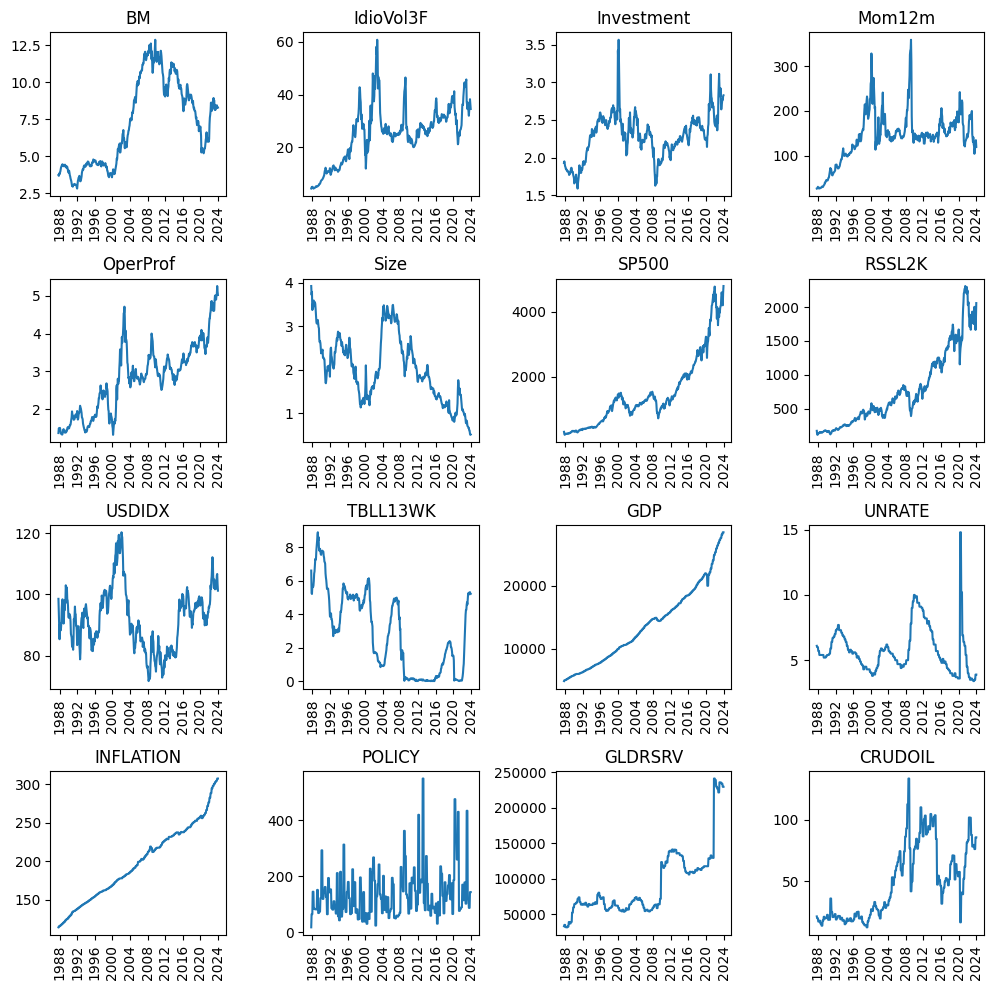

In [6]:
# quick visualization of the processed data
rows = 4
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10,10))
for r in range(rows):
    for c in range(cols):
        axs[r,c].plot(df1.iloc[:, cols*r+c])
        axs[r,c].set_title(df1.columns[cols*r+c])
        axs[r,c].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

In [7]:
# df1.to_csv('data_clean_dynotears_poc.csv')

### 1.3. Data Discretization with Trend Scanning

This **trend scanning** method was taken from Lopez de Prado's book (Machine Learning for Asset Managers, pp. 67-72). The Python implementation below was modified from code adaptations by Endre Moen (https://github.com/emoen/Machine-Learning-for-Asset-Managers).

Basically, this method uses the t-statistics from rolling linear regressions to determine if a stretch of price or index level series is part of an up-trend or a down-trend. I've modified the code so that it can label sideways price movement too (i.e., no trend), so we'll end up with 3 labels or "states".

In [8]:
import statsmodels.api as sm

def tValLinR(close: np.ndarray) -> float:
    """
    Compute the t-statistic of the slope coefficient from an OLS regression
    of `close` values against time.

    Parameters
    ----------
    close : np.ndarray
        Array of values (e.g., prices) in the window.

    Returns
    -------
    float
        t-statistic of the slope coefficient.
    """
    if close.ndim > 1:
        close = close.ravel()

    n = close.shape[0]
    x = np.ones((n, 2))
    x[:, 1] = np.arange(n)
    ols = sm.OLS(close, x).fit()
    return float(ols.tvalues[1])


def getBinsFromTrend(
    molecule: pd.Index,
    close: pd.Series,
    span: tuple[int, int, int], # = (3, 20, 1),
    tval_clip: float = 30.0,
) -> pd.DataFrame:
    """
    Apply the trend-scanning method to generate labels.

    Parameters
    ----------
    molecule : pd.Index
        Subset of indices from `close` to evaluate.
    close : pd.Series
        Price or time series data.
    span : tuple[int, int, int], optional
        Range of window sizes to test (start, stop, step).
        Example: (3, 10, 1) tests windows of size 3..9.
    tval_clip : float, optional
        Maximum absolute value to clip t-statistics at.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - t1: Start time of chosen trend window
        - tVal: t-statistic of chosen window
        - bin: Sign of tVal (+1, -1, or 0)
        - windowSize: Length of chosen window
    """
    hrzns = range(*span)
    minWindow, maxWindow = span[0], span[1] - 1

    out = pd.DataFrame(index=molecule, columns=["t1", "tVal", "bin", "windowSize"])

    for idx in molecule:
        pos = close.index.get_loc(idx)
        if pos < maxWindow:
            continue  # not enough history

        df_tval = pd.Series(dtype="float64")
        for hrzn in hrzns:
            start_pos = pos - hrzn + 1
            if start_pos < 0:
                continue
            dt1 = close.index[start_pos]
            df1 = close.iloc[start_pos : pos + 1]
            df_tval.loc[dt1] = tValLinR(df1.values)

        # Replace problematic values and choose window with strongest |t|
        df_tval = df_tval.replace([-np.inf, np.inf, np.nan], 0.0)
        chosen_start = df_tval.abs().idxmax()
        chosen_tval = df_tval.loc[chosen_start]
        chosen_window = df_tval.abs().values.argmax() + minWindow

        # out.loc[idx, ["t1", "tVal", "bin", "windowSize"]] = (
        #     chosen_start,
        #     chosen_tval,
        #     np.sign(chosen_tval),
        #     chosen_window,
        # )
        
        out.loc[idx, ["t1", "tVal", "windowSize"]] = (
            chosen_start,
            chosen_tval,
            chosen_window,
        )

    out["t1"] = pd.to_datetime(out["t1"])
    out["tVal"] = out["tVal"].astype(float).clip(-tval_clip, tval_clip)
    out["bin"] = pd.qcut(out["tVal"], q=3, labels=False) # modified to include 3 labels / trend states
    # out["bin"] = pd.to_numeric(out["bin"], downcast="signed")

    return out.dropna(subset=["bin"])

In [9]:
# now execute trend scanning & loop over all variables

idx_range_from = 3
idx_range_to = 10

trnd_lbl_df = pd.DataFrame(index=df1.index, columns=df1.columns)

for c in range(len(df1.columns)):

    df3 = pd.Series(index = df1.index, data = df1.iloc[:, c].values)
    df4 = getBinsFromTrend(df3.index, df3, [idx_range_from,idx_range_to,1], 20)
    trnd_lbl_df[df1.columns[c]] = df4['bin']

trnd_lbl_df = trnd_lbl_df.dropna()
trnd_lbl_df.shape

(427, 16)

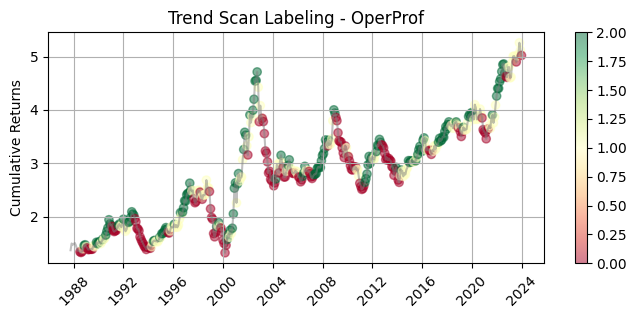

In [10]:
# visualize labels for one of the variables
plt.subplots(figsize=(8,3))
plt.plot(df1.iloc[:,4], color='grey', alpha=0.5)
plt.scatter(trnd_lbl_df.index,
            df1.loc[trnd_lbl_df.index, df1.columns[4]],
            c=trnd_lbl_df.iloc[:,4].values,
            cmap='RdYlGn', alpha=0.5)
plt.colorbar()
plt.grid()
plt.xticks(rotation=45)
plt.ylabel('Cumulative Returns')
plt.title(f'Trend Scan Labeling - {trnd_lbl_df.columns[4]}')
plt.show()

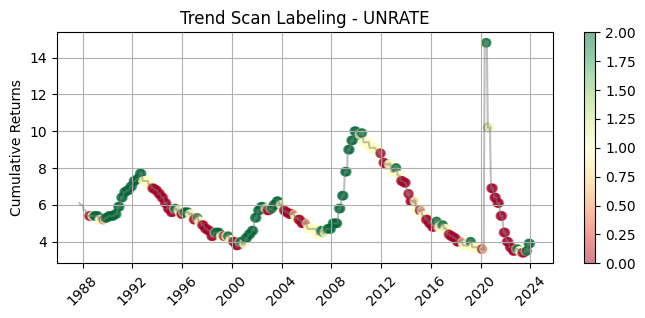

In [11]:
# visualize labels for another one of the variables
plt.subplots(figsize=(8,3))
plt.plot(df1.iloc[:,11], color='grey', alpha=0.5)
plt.scatter(trnd_lbl_df.index,
            df1.loc[trnd_lbl_df.index, df1.columns[11]],
            c=trnd_lbl_df.iloc[:,11].values,
            cmap='RdYlGn', alpha=0.5)
plt.colorbar()
plt.grid()
plt.xticks(rotation=45)
plt.ylabel('Cumulative Returns')
plt.title(f'Trend Scan Labeling - {trnd_lbl_df.columns[11]}')
plt.show()

### 1.4. Train-Test Dataset Split

At the moment, just as a PoC, we'll just perform a single train-test split. In the future, we could implement a walk-forward backtest, with rolling training & testing cycles.

In [12]:
# split data into training & testing sets (80:20 split)

train_data = trnd_lbl_df.iloc[: int(trnd_lbl_df.shape[0] * 0.80)]
test_data = trnd_lbl_df.iloc[int(0.80 * trnd_lbl_df.shape[0]) : int(trnd_lbl_df.shape[0])]

print("Training Set Size: ", train_data.shape)
print("Start of Training Period: ", train_data.index[0])
print("End of Training Period: ", train_data.index[-1])

print("\nTesting Set Size: ", test_data.shape)
print("Start of Testing Period: ", test_data.index[0])
print("End of Testing Period: ", test_data.index[-1])

Training Set Size:  (341, 16)
Start of Training Period:  1988-06-30 00:00:00
End of Training Period:  2016-10-31 00:00:00

Testing Set Size:  (86, 16)
Start of Testing Period:  2016-11-30 00:00:00
End of Testing Period:  2023-12-31 00:00:00


## Section 2 - Bayesian Network

### 2.1. Dynamic BN (DYNOTEARS) Structure Learning

In [13]:
# copy dataframe (just in case) & reset index
trnd_lbl_df1 = train_data.copy()
trnd_lbl_df1 = trnd_lbl_df1.reset_index(drop=True) # dynotears requires integer index

# causal structure learning w/ DYNOTEARS
from causalnex.structure.dynotears import from_pandas_dynamic

csl_grph = from_pandas_dynamic(
    trnd_lbl_df1,
    1,
    lambda_w=0.1,
    lambda_a=0.1,
    w_threshold=0.05,  # keep threshold value low to keep weak links
)

# copy the DAG (just in case) & inspect the edges
grph = deepcopy(csl_grph)
for e in grph.edges:
    print(e)

('BM_lag0', 'Size_lag0')
('BM_lag1', 'BM_lag0')
('IdioVol3F_lag0', 'OperProf_lag0')
('IdioVol3F_lag0', 'INFLATION_lag0')
('IdioVol3F_lag1', 'IdioVol3F_lag0')
('Investment_lag1', 'Investment_lag0')
('Investment_lag1', 'SP500_lag0')
('Mom12m_lag0', 'IdioVol3F_lag0')
('Mom12m_lag0', 'POLICY_lag0')
('Mom12m_lag1', 'Mom12m_lag0')
('OperProf_lag1', 'IdioVol3F_lag0')
('OperProf_lag1', 'Mom12m_lag0')
('OperProf_lag1', 'OperProf_lag0')
('OperProf_lag1', 'POLICY_lag0')
('Size_lag0', 'RSSL2K_lag0')
('Size_lag1', 'Size_lag0')
('SP500_lag0', 'BM_lag0')
('SP500_lag0', 'RSSL2K_lag0')
('SP500_lag0', 'GDP_lag0')
('SP500_lag1', 'SP500_lag0')
('RSSL2K_lag0', 'USDIDX_lag0')
('RSSL2K_lag1', 'Mom12m_lag0')
('RSSL2K_lag1', 'Size_lag0')
('RSSL2K_lag1', 'SP500_lag0')
('RSSL2K_lag1', 'RSSL2K_lag0')
('RSSL2K_lag1', 'INFLATION_lag0')
('USDIDX_lag1', 'USDIDX_lag0')
('TBLL13WK_lag0', 'USDIDX_lag0')
('TBLL13WK_lag0', 'GDP_lag0')
('TBLL13WK_lag1', 'TBLL13WK_lag0')
('GDP_lag0', 'POLICY_lag0')
('GDP_lag1', 'Mom12m_lag0

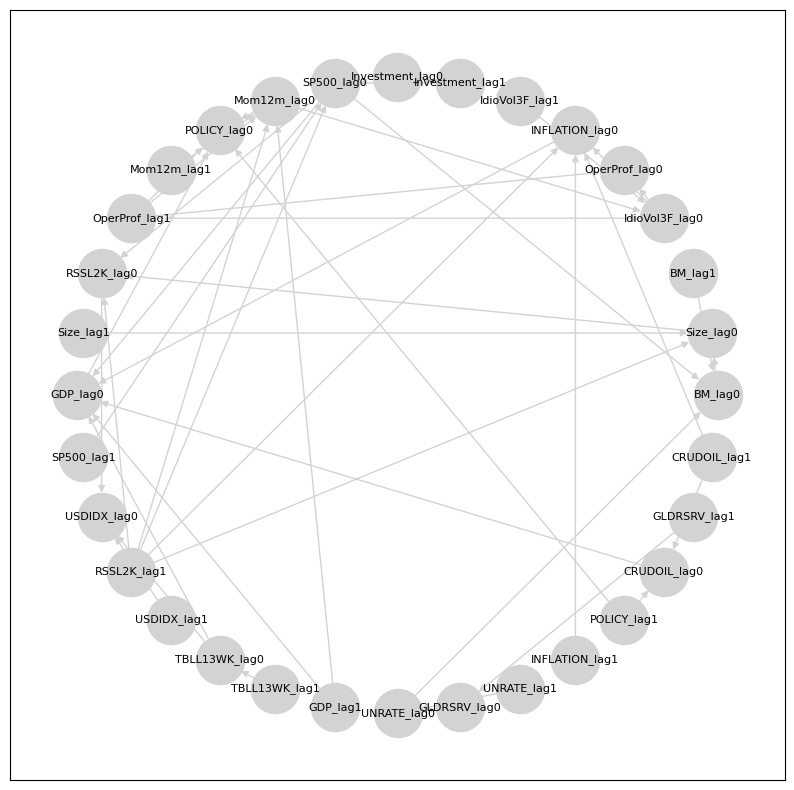

In [14]:
# visualize the estimated DAG structure
import networkx as nx
plt.subplots(figsize=(10,10))
G = nx.DiGraph()
G.add_edges_from(grph.edges)
pos = nx.circular_layout(G)
nx.draw_networkx(G, pos,
                 node_color='lightgrey',
                 node_size=1200,
                 edge_color='lightgrey',
                 font_size=8,
                 font_weight=14)
plt.show()

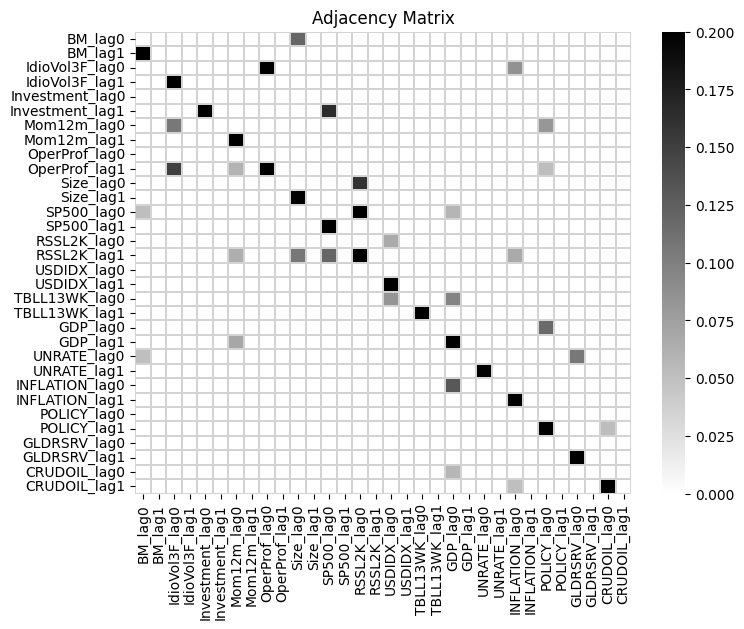

In [15]:
# visualize adjacency matrix
adj_mtx = nx.adjacency_matrix(grph)
adj_mtx_df = pd.DataFrame(data = adj_mtx.toarray(),
                          columns = grph.nodes,
                          index = grph.nodes)
from seaborn import heatmap
plt.subplots(figsize=(8,6))
heatmap(adj_mtx_df,
        linecolor='lightgrey',
        linewidths=0.01,
        vmax=0.2, # lower the max value to observe weak links
        cmap='binary')
plt.title('Adjacency Matrix')
plt.show()

It seems only ```BM_lag1```, ```OperProf_lga1```, ```RSSL2K_lag1```, ```GDP_lag1```, ```SP500_lag0```, and ```UNRATE_lag0``` may have some direct causal influence on the various factors.

### 2.2. Parameter Learning

In [16]:
# create a new BN to be parameterized
from causalnex.network import BayesianNetwork
bn = BayesianNetwork(grph.get_largest_subgraph())

In [17]:
# copy the training dataset
temp_df = train_data.copy()
temp_df.columns = [f'{i}_lag0' for i in trnd_lbl_df1.columns]

# generate lag1 data
for j in temp_df.columns:
    temp_df[f'{j[:-1]}1'] = temp_df[j].shift(-1).fillna(0)

# select variables that are present as nodes in the estimated DAG above
slctd_cols = []
for e in grph.edges:
    for f in range(2):
        if e[f] not in slctd_cols:
            slctd_cols.append(e[f])
        else:
            continue

# fit parameters to the BN
bn = bn.fit_node_states(temp_df)
bn = bn.fit_cpds(temp_df,
                 method = 'BayesianEstimator',
                 bayes_prior = 'K2')

In [18]:
# select variables that are present as nodes in the fitted BN
slctd_cols = []
for e in bn.edges:
    for f in range(2):
        if e[f] not in slctd_cols:
            slctd_cols.append(e[f])
        else:
            continue

# inspect conditional probability tables (CPTs)
# & store in a dict for later, just in case
CPT = {}
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
for i in slctd_cols:
    CPT[i] = bn.cpds[i]
    print(bn.cpds[i])
    print('')

BM_lag1           0.0                                                    \
SP500_lag0        0.0                           1.0                       
UNRATE_lag0       0.0       1.0       2.0       0.0       1.0       2.0   
BM_lag0                                                                   
0.0          0.764706  0.600000  0.619048  0.642857  0.454545  0.692308   
1.0          0.117647  0.333333  0.285714  0.285714  0.272727  0.230769   
2.0          0.117647  0.066667  0.095238  0.071429  0.272727  0.076923   

BM_lag1                                         1.0                        \
SP500_lag0        2.0                           0.0                   1.0   
UNRATE_lag0       0.0       1.0       2.0       0.0       1.0   2.0   0.0   
BM_lag0                                                                     
0.0          0.363636  0.611111  0.615385  0.272727  0.166667  0.28  0.25   
1.0          0.545455  0.277778  0.230769  0.545455  0.500000  0.52  0.40   
2.0         

### 2.3. An Inference Example

In [19]:
from causalnex.inference import InferenceEngine

In [20]:
# copy the testing dataset
temp_df = test_data.copy()
temp_df.columns = [f'{i}_lag0' for i in trnd_lbl_df1.columns]

# generate lag1 data
for j in temp_df.columns:
    temp_df[f'{j[:-1]}1'] = temp_df[j].shift(-1).fillna(0)

# select variables that are present as nodes in the fitted BN
slctd = []
for k in temp_df.columns:
    if k in slctd_cols:
        slctd.append(k)
test_data1 = temp_df.loc[:,slctd]

In [21]:
# make inferences based on the evidence
ie = InferenceEngine(bn)

# Example: based on selected relevant 'lag1' evidence on the 1st test data time point
evdnc = test_data1.loc[test_data1.index[0], ['GDP_lag1',
                                             'RSSL2K_lag1',
                                             'BM_lag1',
                                             'Investment_lag1',
                                             'OperProf_lag1']].to_dict()
mrgnls = ie.query(evdnc) # this is a dictionary the inference engine produces

# print the marginal probabilities given the evidence
for m in mrgnls.keys():
    print(m)
    for n, x in enumerate(mrgnls[m].values()):
        print(f'{n}\t{x: .3f}')

BM_lag0
0	 0.110
1	 0.244
2	 0.646
Size_lag0
0	 0.281
1	 0.320
2	 0.400
BM_lag1
0	 0.000
1	 0.000
2	 1.000
IdioVol3F_lag0
0	 0.306
1	 0.343
2	 0.351
OperProf_lag0
0	 0.173
1	 0.531
2	 0.296
INFLATION_lag0
0	 0.323
1	 0.295
2	 0.381
IdioVol3F_lag1
0	 0.340
1	 0.326
2	 0.334
Investment_lag1
0	 0.000
1	 0.000
2	 1.000
Investment_lag0
0	 0.065
1	 0.194
2	 0.742
SP500_lag0
0	 0.279
1	 0.423
2	 0.299
Mom12m_lag0
0	 0.441
1	 0.246
2	 0.313
POLICY_lag0
0	 0.338
1	 0.346
2	 0.316
Mom12m_lag1
0	 0.326
1	 0.317
2	 0.358
OperProf_lag1
0	 0.000
1	 1.000
2	 0.000
RSSL2K_lag0
0	 0.232
1	 0.470
2	 0.298
Size_lag1
0	 0.314
1	 0.323
2	 0.363
GDP_lag0
0	 0.294
1	 0.311
2	 0.395
SP500_lag1
0	 0.340
1	 0.334
2	 0.326
USDIDX_lag0
0	 0.336
1	 0.345
2	 0.319
RSSL2K_lag1
0	 0.000
1	 1.000
2	 0.000
USDIDX_lag1
0	 0.352
1	 0.337
2	 0.311
TBLL13WK_lag0
0	 0.355
1	 0.372
2	 0.274
TBLL13WK_lag1
0	 0.358
1	 0.372
2	 0.270
GDP_lag1
0	 0.000
1	 1.000
2	 0.000
UNRATE_lag0
0	 0.297
1	 0.328
2	 0.375
GLDRSRV_lag0
0	 0.33

In [22]:
# extract the probabilities for the factors from the inference above & store in a dataframe
fctr_mrgnls = pd.DataFrame(index = [0, 1, 2])
for k in test_data1.columns[:6]:
    fctr_mrgnls[k] = mrgnls[k]
fctr_mrgnls.columns = [k[:-5] for k in fctr_mrgnls.columns] # drop 'lag_0' from col names
fctr_mrgnls

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,0.109503,0.306003,0.064516,0.441314,0.172831,0.280540
1,0.244480,0.342828,0.193548,0.246018,0.531471,0.319919
2,0.646017,0.351169,0.741935,0.312667,0.295697,0.399541


## Section 3 - Weight Allocation Optimization

### 3.1. State-Dependent Returns & Covariance Estimation

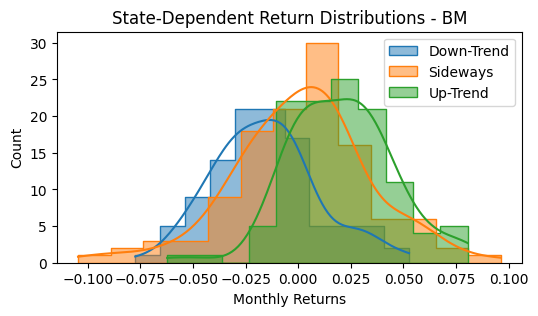

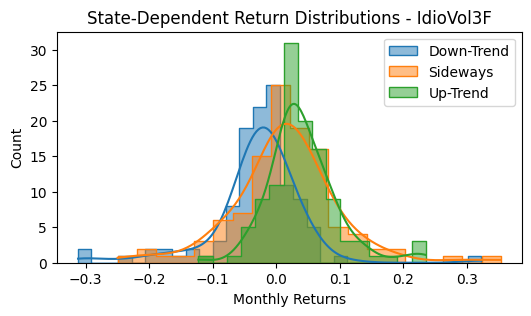

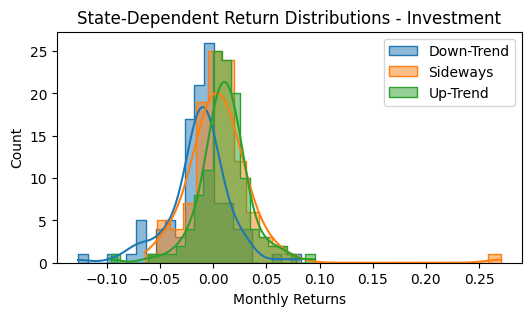

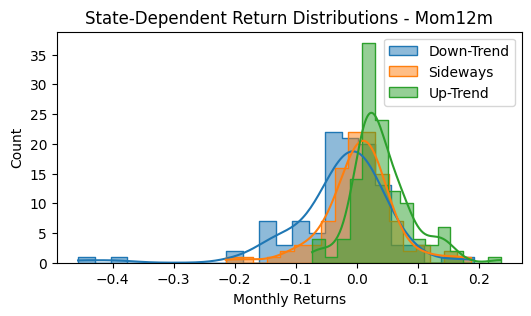

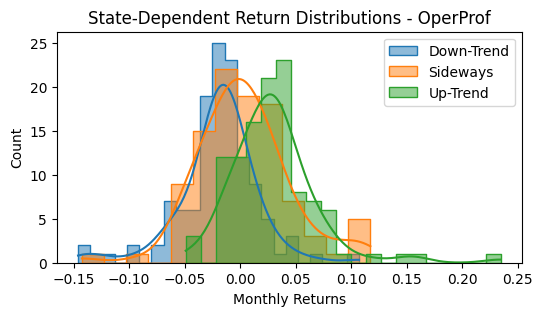

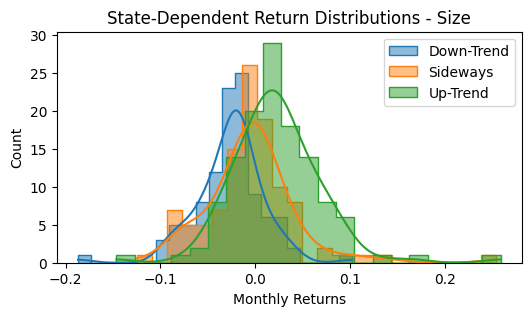

In [23]:
# first, we calculate the mean & std of returns for e/a state (trend) for e/a factor (from training data)
df2 = df1.copy().loc[train_data.index, df1.columns[:6]].pct_change().dropna()

ret_state = pd.DataFrame(index = [0, 1, 2])
temp0 = pd.DataFrame()

for v in df1.columns[:6]:

    temp0['ret'] = df2.loc[train_data.index[1:], v]
    temp0['state'] = trnd_lbl_df.loc[train_data.index[1:], v].values

    # visualize the state-dependent return distributions to check
    from seaborn import histplot
    lbl = ['Down-Trend', 'Sideways', 'Up-Trend']
    plt.subplots(figsize=(6,3))
    for x in range(3):
        histplot(temp0['ret'].loc[temp0['state'] == x],
                 kde=True,
                 element='step',
                 label=lbl[x])
    plt.legend()
    plt.xlabel('Monthly Returns')
    plt.title(f'State-Dependent Return Distributions - {v}')
    plt.show()

    temp1 = temp0.groupby('state')['ret'].agg(['mean'])
    ret_state[v] = temp1['mean']

In [24]:
# inspect state-dependent mean returns for each factor
ret_state

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,-0.015684,-0.029233,-0.013318,-0.025879,-0.019625,-0.026461
1,0.001435,0.014433,0.006006,0.004668,0.002865,-0.004393
2,0.020270,0.041387,0.010387,0.041416,0.030024,0.022406


In [25]:
# adjust returns by marginal probabilities
adj_ret_state = fctr_mrgnls * ret_state
adj_ret_state

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,-0.001717,-0.008946,-0.000859,-0.011421,-0.003392,-0.007423
1,0.000351,0.004948,0.001162,0.001148,0.001523,-0.001405
2,0.013095,0.014534,0.007707,0.012949,0.008878,0.008952


This makes sense since the average returns of a down-trend (state = 0) is generally negative, whereas that of an up-trend (state = 2) is positive.

In [26]:
# create arrays for annualize mean returns for e/a state for downstream calculations
mu_0 = np.array(adj_ret_state.iloc[0,:] * 12)
mu_1 = np.array(adj_ret_state.iloc[1,:] * 12)
mu_2 = np.array(adj_ret_state.iloc[2,:] * 12)

In [27]:
# estimate state-dependent covariant matrices for downstream calculations

s_0 = df2['BM'].loc[trnd_lbl_df['BM'] == 0]
s_1 = df2['BM'].loc[trnd_lbl_df['BM'] == 1]
s_2 = df2['BM'].loc[trnd_lbl_df['BM'] == 2]

# this is a crude estimation since the factors are often in different trends at any given time
for v in df1.columns[1:6]:
    x = pd.concat([s_0, df2[v].loc[trnd_lbl_df[v] == 0]], axis=1, join='outer').fillna(0)
    s_0 = x
    y = pd.concat([s_1, df2[v].loc[trnd_lbl_df[v] == 1]], axis=1, join='outer').fillna(0)
    s_1 = y
    z = pd.concat([s_2, df2[v].loc[trnd_lbl_df[v] == 2]], axis=1, join='outer').fillna(0)
    s_2 = z

# generate estimated annualized covariance matrices
Sigma_0 = s_0.cov() * 12
Sigma_1 = s_1.cov() * 12
Sigma_2 = s_2.cov() * 12

### 3.2. Factor Weight Optimization

#### 3.2.1. Weight Allocations Based on Traditional MVO

In [28]:
# Mean-Variance Optimization
import scipy.optimize as sco

def calc_neg_sharpe(weights, mean_returns, cov, rf):
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    sharpe_ratio = (portfolio_return - rf) / portfolio_std
    return -sharpe_ratio

def max_sharpe_ratio(mean_returns, cov, rf):
    num_assets = len(mean_returns)
    args = (mean_returns, cov, rf)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bound = (0.0, 1.0)    # a long-short portfolio would be: bound = (-1.0, 1.0) 
    bounds = tuple(bound for asset in range(num_assets))
    result = sco.minimize(calc_neg_sharpe, num_assets*[1./num_assets,], args=args,
                        method='SLSQP', bounds=bounds, constraints=constraints)
    return result

In [29]:
# risk-free rate = 0% for simplicity
rf = 0.0

# define annualized mean returns vector (mu) & covariance matrix (Sigma)
mu_mvo = df2.mean() * 12
Sigma_mvo = df2.cov() * 12

In [30]:
# maximum Sharpe ratio factor portfolio based on MVO
sharpe_opt_mvo = max_sharpe_ratio(mu_mvo, Sigma_mvo, rf)
print(sharpe_opt_mvo)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.6728688355070587
       x: [ 4.525e-01  1.874e-01  2.077e-01  1.363e-01  1.603e-02
            3.769e-17]
     nit: 6
     jac: [ 1.439e-04 -6.647e-05  4.194e-05 -4.036e-04 -3.961e-04
            1.255e-01]
    nfev: 44
    njev: 6


In [31]:
mvo_port = pd.DataFrame([round(x,4) for x in sharpe_opt_mvo['x']], index=df2.columns)
mvo_port.T

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,0.4525,0.1874,0.2077,0.1363,0.016,0.0


#### 3.2.2. Weight Allocations Based on DBN Model

In [32]:
# first, we'll estimate the average probability of each state
for x in trnd_lbl_df.columns[:6]:
    print(f"\n{x}")
    for y in range(3):
        print(f"P(S={y}): {trnd_lbl_df[x].loc[trnd_lbl_df[x] == y].shape[0] / trnd_lbl_df.shape[0]:.4f}")


BM
P(S=0): 0.3326
P(S=1): 0.3326
P(S=2): 0.3349

IdioVol3F
P(S=0): 0.3326
P(S=1): 0.3349
P(S=2): 0.3326

Investment
P(S=0): 0.3326
P(S=1): 0.3326
P(S=2): 0.3349

Mom12m
P(S=0): 0.3326
P(S=1): 0.3326
P(S=2): 0.3349

OperProf
P(S=0): 0.3326
P(S=1): 0.3349
P(S=2): 0.3326

Size
P(S=0): 0.3326
P(S=1): 0.3326
P(S=2): 0.3349


Roughly speaking, each state appears 1/3 of the time.

In [33]:
# calculate combined / mixture expected mean returns & covariance
mus = [mu_0, mu_1, mu_2]
Sigmas = [Sigma_0, Sigma_1, Sigma_2]
p0 = p1 = p2 = 1/3
pis = np.array([p0, p1, p2])

# calculate mixture mean
mu_bar = sum(pi * mu for pi, mu in zip(pis, mus))

# calculate mixture covariance
Sigma_mix = np.zeros((6, 6))
for pi, mu, Sigma in zip(pis, mus, Sigmas):
    Sigma_mix += pi * (Sigma + np.outer(mu - mu_bar, mu - mu_bar))


In [34]:
# maximum Sharpe ratio factor portfolio based on DBN model
sharpe_opt_dbn = max_sharpe_ratio(mu_bar, Sigma_mix, rf)
print(sharpe_opt_dbn)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -0.5124648147586729
       x: [ 4.669e-01  1.053e-16  4.376e-01  6.078e-16  9.554e-02
            7.815e-16]
     nit: 7
     jac: [-7.620e-05  5.761e-02 -7.287e-06  5.083e-01  4.057e-04
            5.424e-01]
    nfev: 49
    njev: 7


In [35]:
dbn_port = pd.DataFrame([round(x,4) for x in sharpe_opt_dbn['x']], index=df2.columns)
dbn_port.T

,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
0,0.4669,0.0,0.4376,0.0,0.0955,0.0


In [36]:
# compare weight allocations based on MVO and DBN
cmpr_port = pd.concat([mvo_port, dbn_port], axis=1)
cmpr_port.columns = ['MVO', 'DBN']
cmpr_port

,MVO,DBN
BM,0.4525,0.4669
IdioVol3F,0.1874,0.0000
Investment,0.2077,0.4376
Mom12m,0.1363,0.0000
OperProf,0.0160,0.0955
Size,0.0000,0.0000


## Section 4 - Walk-Forward Backtest

Next, the procedure above is implemented on a rolling basis. Again, because this is just a PoC, factor weights  are rebalanced every month without any model re-training. The results will be compared with the static weight allocations from MVO above.

Starting from ```t = 0``` on the testing set:
1. Observed the state of ```GDP```, ```RSSL2K```, ```BM```, ```Investment```, ```OperProf```.
2. Treat them as ```lag1``` data observations.
3. Perform inference for the next time point (```lag0```) based on these observations.
4. Calculate mixture expected mean returns.
5. Perform weight optimization & construct a portfolio.
6. Repeat in the next time point until the end of evaluation period.

In [37]:
# an array to store weights
wghts_dbn = np.empty((test_data1.shape[0], 6))
wghts_dbn[:] = np.nan

for w in range(1,test_data1.shape[0]):

    # make inferences based on the evidence
    ie = InferenceEngine(bn)

    # based on selected relevant 'lag1' evidence
    evdnc = test_data1.loc[test_data1.index[w], ['GDP_lag1',
                                                'RSSL2K_lag1',
                                                'BM_lag1',
                                                'Investment_lag1',
                                                'OperProf_lag1']].to_dict()
    mrgnls = ie.query(evdnc) # this is a dictionary the inference engine produces

    # extract the probabilities for the factors from the inference above & store in a dataframe
    fctr_mrgnls = pd.DataFrame(index = [0, 1, 2])
    for k in test_data1.columns[:6]:
        fctr_mrgnls[k] = mrgnls[k]
    fctr_mrgnls.columns = [k[:-5] for k in fctr_mrgnls.columns] # drop 'lag_0' from col names

    # adjust returns by marginal probabilities
    adj_ret_state = fctr_mrgnls * ret_state

    # create arrays for annualize mean returns for e/a state for downstream calculations
    mu_0 = np.array(adj_ret_state.iloc[0,:] * 12)
    mu_1 = np.array(adj_ret_state.iloc[1,:] * 12)
    mu_2 = np.array(adj_ret_state.iloc[2,:] * 12)

    # calculate combined / mixture expected mean returns & covariance
    mus = [mu_0, mu_1, mu_2]

    # calculate mixture mean
    # the mixture covariance matrices are assumed to be non-time-varying
    mu_bar = sum(pi * mu for pi, mu in zip(pis, mus))

    # maximum Sharpe ratio factor portfolio based on MVO & DBN model
    sharpe_opt_dbn = max_sharpe_ratio(mu_bar, Sigma_mix, rf)

    # store optimized weights
    wghts_dbn[w,:] = sharpe_opt_dbn['x']

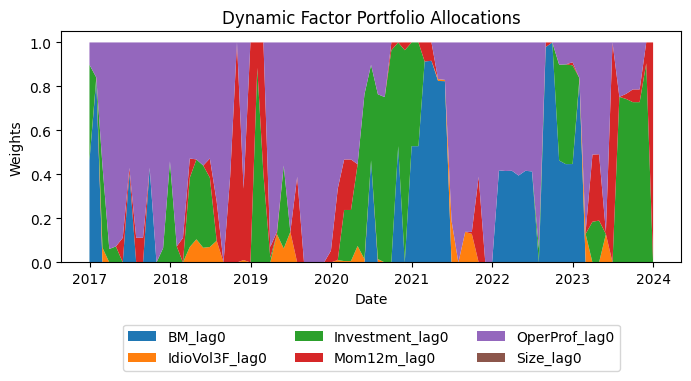

In [38]:
# visualize changes in weight allocations over time
w_df = pd.DataFrame(wghts_dbn, columns=test_data1.columns[:6], index=test_data.index)

plt.subplots(figsize=(8,3))
plt.stackplot(w_df.index, w_df.T)
plt.ylabel('Weights')
plt.xlabel('Date')
plt.legend(test_data1.columns[:6],loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.5))
plt.title('Dynamic Factor Portfolio Allocations')
plt.show()

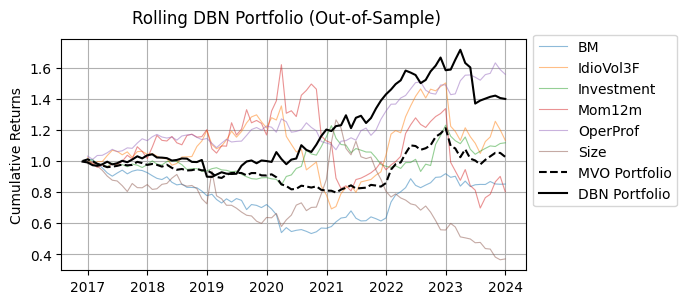

In [39]:
# fee is assumed to be 5% per annum charged monthly
fee = 0.05 / 12

# calculate returns from the test dataset
df3 = df1.copy().loc[test_data.index, df1.columns[:6]].pct_change()

mvo_ret = sharpe_opt_mvo['x'] * df3
mvo_port = (1 + mvo_ret.sum(axis=1)).cumprod()
dbn_ret = wghts_dbn * df3.shift(-1)
dbn_port = (1 + dbn_ret.sum(axis=1) - fee).cumprod()

# plot testing dataset cumulative returns
plt.subplots(figsize = (6, 3))
plt.plot((1 + df3).cumprod(),
         linewidth = 0.8, alpha = 0.5, label = df3.columns)
plt.plot(mvo_port, label = 'MVO Portfolio', c = 'black', linestyle = '--')
plt.plot(dbn_port, label = 'DBN Portfolio', c = 'black')
plt.ylabel('Cumulative Returns')
plt.suptitle("Rolling DBN Portfolio (Out-of-Sample)")
plt.legend(bbox_to_anchor = (1, 1.05))
plt.grid()
plt.show()

In [40]:
# functions to calculate performance metrics

def drawdown(ret):

    # cum_ret: cumulative returns pandas series
    # returns drawdown series

    cumul_ret = cum_ret(ret)
    cumul_max = cumul_ret.cummax()
    drwdwn =  (cumul_ret / cumul_max) - 1

    return drwdwn

def sharpe_ratio(ret, rf = 0):

    # ret: daily simple returns pandas series
    # rf: risk-free rate (default 0 for simplicity)
    # returns annualized Sharpe ratio

    ann_shrp = np.sqrt(12) * (ret.mean() - rf) / ret.std()

    return ann_shrp

def cum_ret(ret):

    # ret: daily simple returns pandas series
    # returns umulative returns series

    cumul_ret = (1 + ret).cumprod() # - 1

    return cumul_ret

def CAGR(ret):

    # ret: daily simple returns pandas series
    # returns umulative returns series

    cumul_ret = cum_ret(ret)
    cagr = (cumul_ret.iloc[-1] / cumul_ret.iloc[0]) ** (1 / (len(ret) / 12)) - 1

    return cagr

In [41]:
print('Mean-Variance Optimized Portfolio (Out-of-Sample)')
print("Cumulative Returns:\t", round(mvo_port.iloc[-1], 3))
print("CAGR:\t\t\t", round(CAGR(mvo_ret.sum(axis=1)), 3))
print("Sharpe Ratio:\t\t", round(sharpe_ratio(mvo_ret.sum(axis=1)), 3))
print("Max Drawdown:\t\t", round(drawdown(mvo_ret.sum(axis=1)).min(), 3))

print('\nDynamic Bayesian Model Portfolio (Out-of-Sample)')
print("Cumulative Returns:\t", round(dbn_port.iloc[-1], 3))
print("CAGR:\t\t\t", round(CAGR(dbn_ret.sum(axis=1)), 3))
print("Sharpe Ratio:\t\t", round(sharpe_ratio(dbn_ret.sum(axis=1)), 3))
print("Max Drawdown:\t\t", round(drawdown(dbn_ret.sum(axis=1)).min(), 3))

Mean-Variance Optimized Portfolio (Out-of-Sample)
Cumulative Returns:	 1.026
CAGR:			 0.004
Sharpe Ratio:		 0.085
Max Drawdown:		 -0.211

Dynamic Bayesian Model Portfolio (Out-of-Sample)
Cumulative Returns:	 1.399
CAGR:			 0.101
Sharpe Ratio:		 0.894
Max Drawdown:		 -0.191
